In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

df = pd.read_csv('./results/grg_comparison.csv')

METHODS    = ['s_gd2', 'TorusMDS']
COLORS     = {'s_gd2': '#4C72B0', 'TorusMDS': '#DD8452'}
GT_COLORS  = {'euclidean': '#7BB3D4', 'toroidal': '#E8896A'}   # tints for graph-type plots
GT_HATCH   = {'euclidean': '', 'toroidal': '///'}
GRAPH_TYPES = ['euclidean', 'toroidal']
METRICS    = ['stress', 'np_score']
LABELS     = {
    'stress':     'Normalized stress',
    'distortion': 'Distortion',
    'sgs':        'SGS (Spearman rank corr.)',
    'np_score':   'Neighbourhood preservation',
    't_embed':    'Embedding time (s)',
}

TOROIDAL_ONLY = True
if TOROIDAL_ONLY:
    df = df[df['graph_type'] == 'toroidal']

data = {m: df[df['method'] == m] for m in METHODS}
print('--- overall ---')
print(df.groupby('method')[METRICS + ['t_embed']].agg(['mean','std']).round(4))
print('\n--- by graph type ---')
print(df.groupby(['method', 'graph_type'])[METRICS].mean().round(4))

--- overall ---
          stress         np_score         t_embed        
            mean     std     mean     std    mean     std
method                                                   
MDS       0.3168  0.0404   0.7444  0.2102  1.8783  3.0151
TorusMDS  0.1645  0.0440   0.9102  0.1028  1.8744  0.7129
s_gd2     0.3349  0.0426   0.7316  0.2221  0.1936  0.2806

--- by graph type ---
                     stress  np_score
method   graph_type                  
MDS      toroidal    0.3168    0.7444
TorusMDS toroidal    0.1645    0.9102
s_gd2    toroidal    0.3349    0.7316


## Violin plots

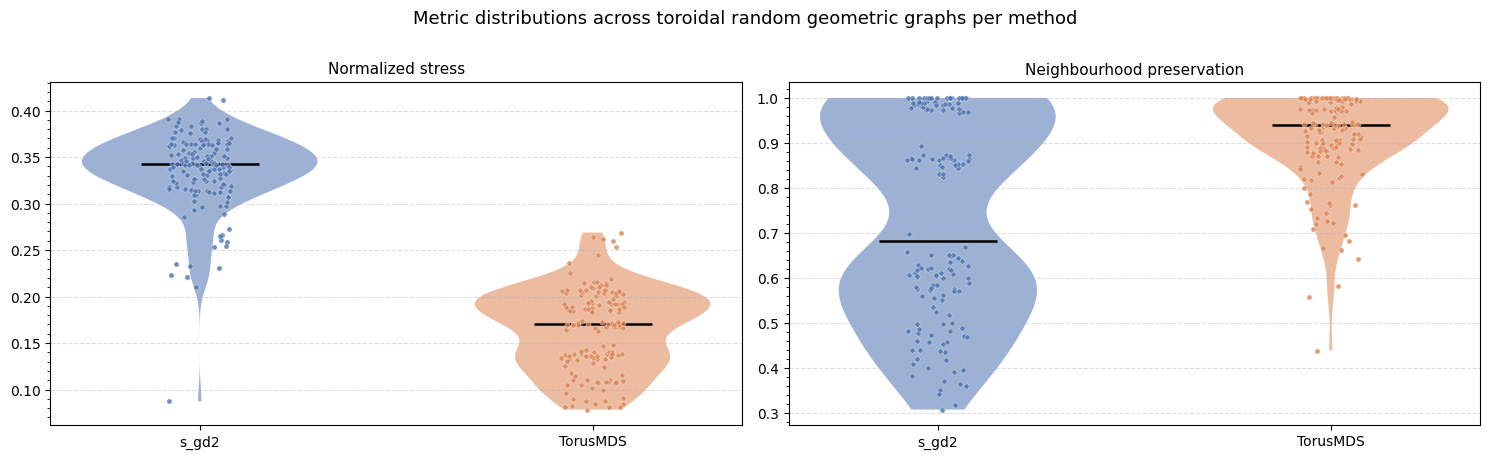

In [2]:
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

for ax, metric in zip(axes, METRICS):
    parts = ax.violinplot(
        [data[m][metric].values for m in METHODS],
        positions=range(len(METHODS)),
        widths=0.6,
        showmedians=True,
        showextrema=False,
    )
    for pc, m in zip(parts['bodies'], METHODS):
        pc.set_facecolor(COLORS[m])
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.8)

    for xi, m in enumerate(METHODS):
        vals = data[m][metric].values
        jitter = rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(xi + jitter, vals, s=14, color=COLORS[m],
                   edgecolors='white', linewidths=0.3, zorder=3, alpha=0.8)

    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS, fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis='y', which='major', linestyle='--', alpha=0.4)

fig.suptitle('Metric distributions across toroidal random geometric graphs per method', fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig('./results/grg_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Metrics vs graph size n

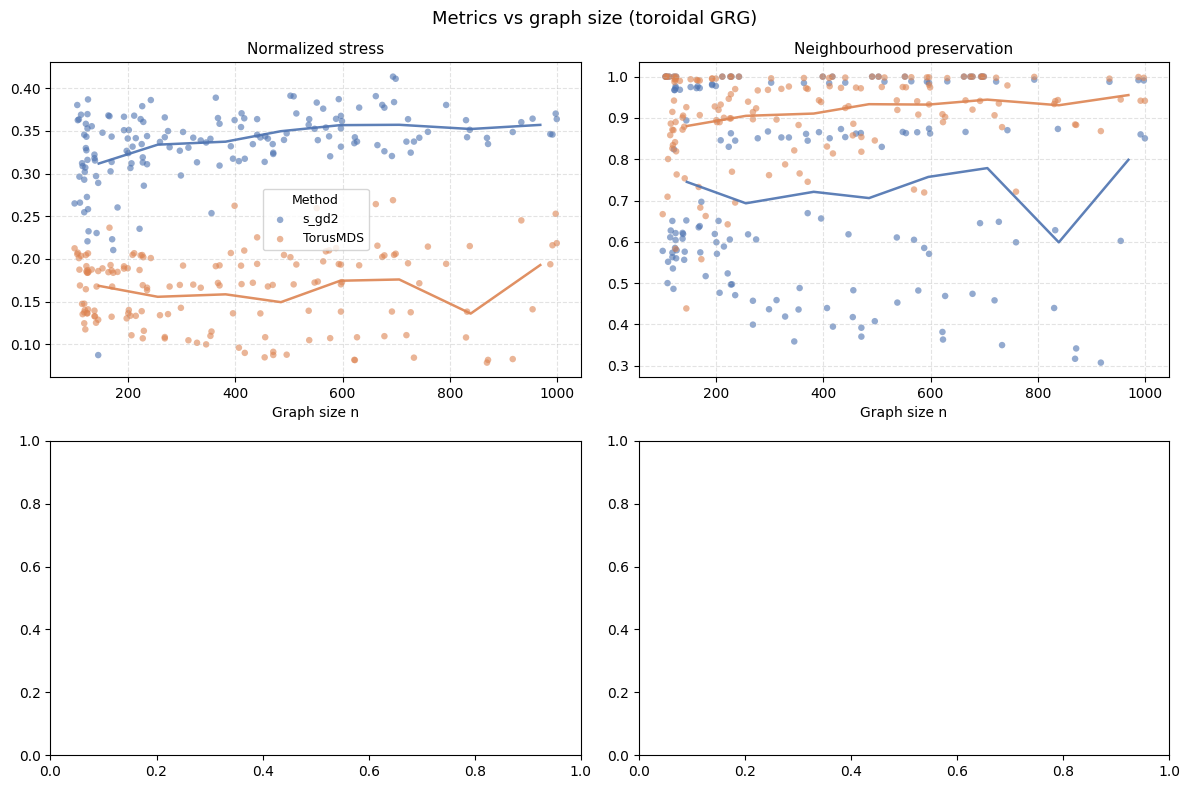

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, metric in zip(axes.flat, METRICS):
    for m in METHODS:
        d = data[m].sort_values('n')
        ax.scatter(d['n'], d[metric], s=22, color=COLORS[m],
                   alpha=0.6, label=m, edgecolors='none')
        # LOWESS-style trend via binned means
        bins = pd.cut(d['n'], bins=8)
        trend = d.groupby(bins, observed=True)[metric].mean()
        mids  = d.groupby(bins, observed=True)['n'].mean()
        ax.plot(mids.values, trend.values, color=COLORS[m], linewidth=1.8, alpha=0.9)

    ax.set_xlabel('Graph size n', fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.grid(linestyle='--', alpha=0.35)

axes.flat[0].legend(title='Method', fontsize=9, title_fontsize=9)
fig.suptitle('Metrics vs graph size (toroidal GRG)', fontsize=13)
fig.tight_layout()
plt.savefig('./results/grg_metrics_vs_n.png', dpi=150, bbox_inches='tight')
plt.show()

## Running time distributions

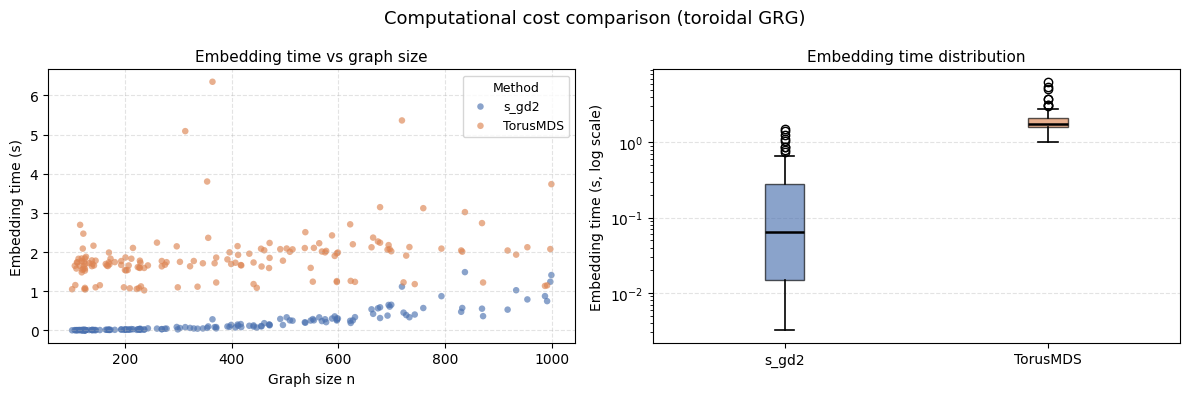

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: scatter t_embed vs n
ax = axes[0]
for m in METHODS:
    d = data[m]
    ax.scatter(d['n'], d['t_embed'], s=22, color=COLORS[m],
               alpha=0.65, label=m, edgecolors='none')
ax.set_xlabel('Graph size n', fontsize=10)
ax.set_ylabel('Embedding time (s)', fontsize=10)
ax.set_title('Embedding time vs graph size', fontsize=11)
ax.legend(title='Method', fontsize=9, title_fontsize=9)
ax.grid(linestyle='--', alpha=0.35)

# Right: log-scale box plot
ax = axes[1]
bp = ax.boxplot(
    [data[m]['t_embed'].values for m in METHODS],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.8),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)
for patch, m in zip(bp['boxes'], METHODS):
    patch.set_facecolor(COLORS[m])
    patch.set_alpha(0.65)
ax.set_yscale('log')
ax.set_xticks(range(1, len(METHODS) + 1))
ax.set_xticklabels(METHODS, fontsize=10)
ax.set_ylabel('Embedding time (s, log scale)', fontsize=10)
ax.set_title('Embedding time distribution', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.yaxis.set_minor_locator(mticker.LogLocator(subs='all', numticks=10))

fig.suptitle('Computational cost comparison (toroidal GRG)', fontsize=13)
fig.tight_layout()
plt.savefig('./results/grg_timing.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary table

In [5]:
summary = df.groupby('method')[METRICS + ['t_embed']].agg(['mean', 'median', 'std'])
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.round(4)
summary

,stress_mean,stress_median,stress_std,np_score_mean,np_score_median,np_score_std,t_embed_mean,t_embed_median,t_embed_std
method,,,,,,,,,
MDS,0.3168,0.3266,0.0404,0.7444,0.6714,0.2102,1.8783,0.3202,3.0151
TorusMDS,0.1645,0.1702,0.0440,0.9102,0.9398,0.1028,1.8744,1.7604,0.7129
s_gd2,0.3349,0.3421,0.0426,0.7316,0.6831,0.2221,0.1936,0.0646,0.2806
